## Executive Summary

This EDA explores the **[Student Placement Prediction Dataset 2026](https://www.kaggle.com/datasets/sehaj1104/student-placement-prediction-dataset-2026)** to understand how student demographics, academics, skills, and experience relate to **placement status** and (for placed students) **salary package (LPA)**.

* **Data quality & structural validity:** The dataset contains **100,000 rows and 25 columns**, with **no missing values** and **no duplicate rows**. Salary is structurally consistent: **all “Not Placed” students have `salary_package_lpa = 0.0`**.
* **Overall placement outcome:** **54,459 out of 100,000 students are placed (~54.5%)**.
* **Salary outcomes (placed only):** Salaries are concentrated around ~13 LPA: **mean ≈ 13.32 LPA**, **median ≈ 13.30 LPA**, **IQR ≈ 12.23–14.39 LPA**, with observed values ranging from **~7.11 to ~20.44 LPA**.
* **Distribution insights:** Many score-based features are approximately normally distributed, while `salary_package_lpa` is **zero-inflated** due to unplaced students (spike at 0). This supports analyzing salary **only among placed students**.
* **Key relationships:** Salary shows the strongest positive association with **`cgpa`**, followed by **`coding_skill_score`** and **`internships_count`**. Variables like **`linkedin_connections`** and **`study_hours_per_day`** show little to no relationship with salary. Score distributions for placed vs unplaced students show substantial overlap, suggesting limited separation using individual scores alone.
* **Group comparisons:** Salary distributions appear broadly similar across **branch** and **college tier**, with no strong visual differences in medians or spread.

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

pd.set_option('display.max_columns', None)

/opt/anaconda3/envs/data_science/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub
import pandas as pd
from pathlib import Path

path = kagglehub.dataset_download("sehaj1104/student-placement-prediction-dataset-2026")

df = pd.read_csv(f"{path}/student_placement_prediction_dataset_2026.csv")
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,1,184,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,2,539,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,2,568,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,1,550,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,4,833,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [3]:
df.tail()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,56.904150,87.245760,43.013761,0,5,495,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,55.729008,42.767277,62.381626,0,2,958,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,48.725390,72.394081,70.888580,0,6,272,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,79.336599,45.375535,52.091126,0,6,576,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00
99999,100000,22,Female,8.58,ECE,Tier 3,1,3,2,92.146277,89.261932,81.629165,94.963205,0,1,812,77.864288,89.919640,0,48.363818,21.166444,Yes,6.5,2.9,Placed,14.43


In [4]:
# Check the shape of the DataFrame
print("Number of Rows",df.shape[0])
print("Number of Columns",df.shape[1])

Number of Rows 100000
Number of Columns 26


In [5]:
# Print column names of the DataFrame
print("Columns Names : ", df.columns)

Columns Names :  Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')


In [6]:
# Checking for any null values
df.isnull().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [7]:
# Check for any duplicated rows
num_duplicates = len(df[df.duplicated()])
print("Number of duplicated rows:", num_duplicates)

Number of duplicated rows: 0


In [8]:
# Validate that students who are not placed have a salary package of 0.0
unplaced_salary = df.loc[df.placement_status == "Not Placed", "salary_package_lpa"]
all_zero_salary = (unplaced_salary == 0.0).all()
print(f"All students with 'Not Placed' status have a salary package of 0.0: {all_zero_salary}")


All students with 'Not Placed' status have a salary package of 0.0: True


# Summary Statistics
The dataset is split into two subsets: one containing categorical variables and the other numerical variables. Univariate analysis is conducted to determine the overall student placement rate and to examine the distribution of salary packages. Understanding the salary distribution will also help inform potential future modeling decisions.

In [9]:
# Drop unnecessary columns that don't provide insight to analysis
df = df.drop(columns=['student_id'])

In [10]:
# Separate categorical and numerical columns
cat_columns = df.select_dtypes(include=['object']).columns
num_columns = df.select_dtypes(exclude=['object']).columns

In [11]:
# Summary statistics of numerical columns
df[num_columns].describe()

,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,1.000690,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,0.997908,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,0.000000,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,0.000000,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,1.000000,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,2.000000,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,8.000000,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


From the table, aptitude features such as `coding_skill_score` and `logical_reasoning_score` are measured out of 100, placing them on a larger scale than variables like `age` or `certifications_count`. To prevent these higher-magnitude features from disproportionately influencing future models, they will require scaling. Similarly, non-score features such as `linkedin_connections` and `attendance_percentage` also require scaling. For `attendance_percentage`, a simple transformation (dividing by 100) will normalize it to a 0–1 range.

In [12]:
# Summary statistics of categorical columns
df[cat_columns].describe()

,gender,branch,college_tier,volunteer_experience,placement_status
count,100000,100000,100000,100000,100000
unique,2,6,3,2,2
top,Male,CSE,Tier 2,No,Placed
freq,60028,34818,49955,59963,54459


In [13]:
# Calculation of placement rate
placement_rate = (df["placement_status"] == "Placed").mean() * 100
print(f"Overall placement rate: {placement_rate:.1f}%")

Overall placement rate: 54.5%


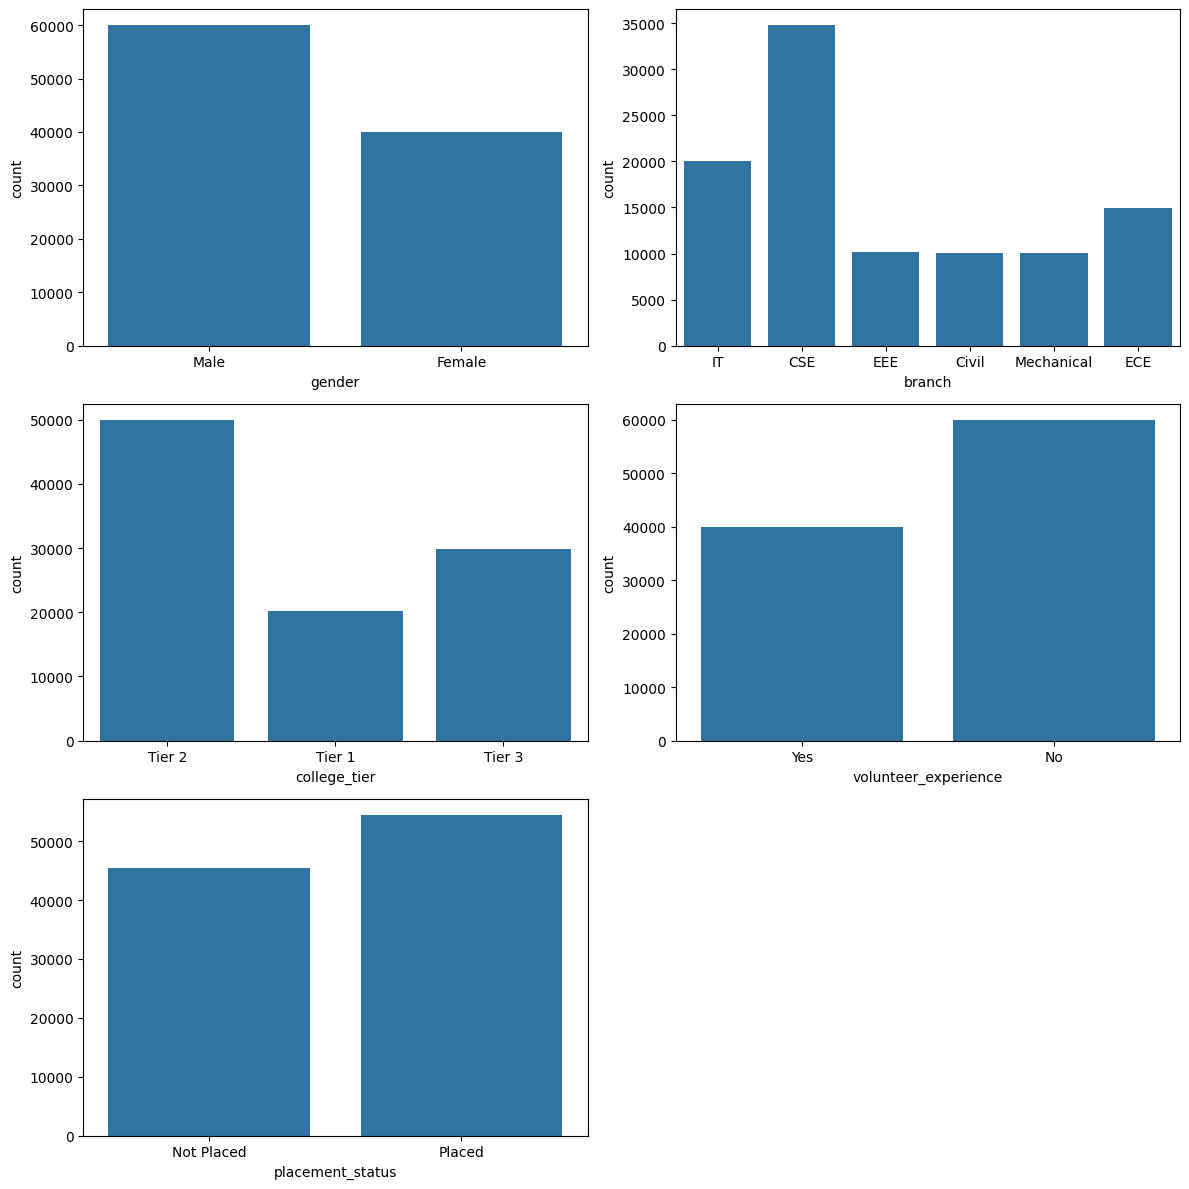

In [14]:
# Plotting count plots of categorical columns
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_columns):
    sns.countplot(x=col, data=df, ax=ax)

for i in range(len(cat_columns), 6):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


From the count plots, the category distributions appear relatively balanced, with no single level overwhelmingly dominating the others.

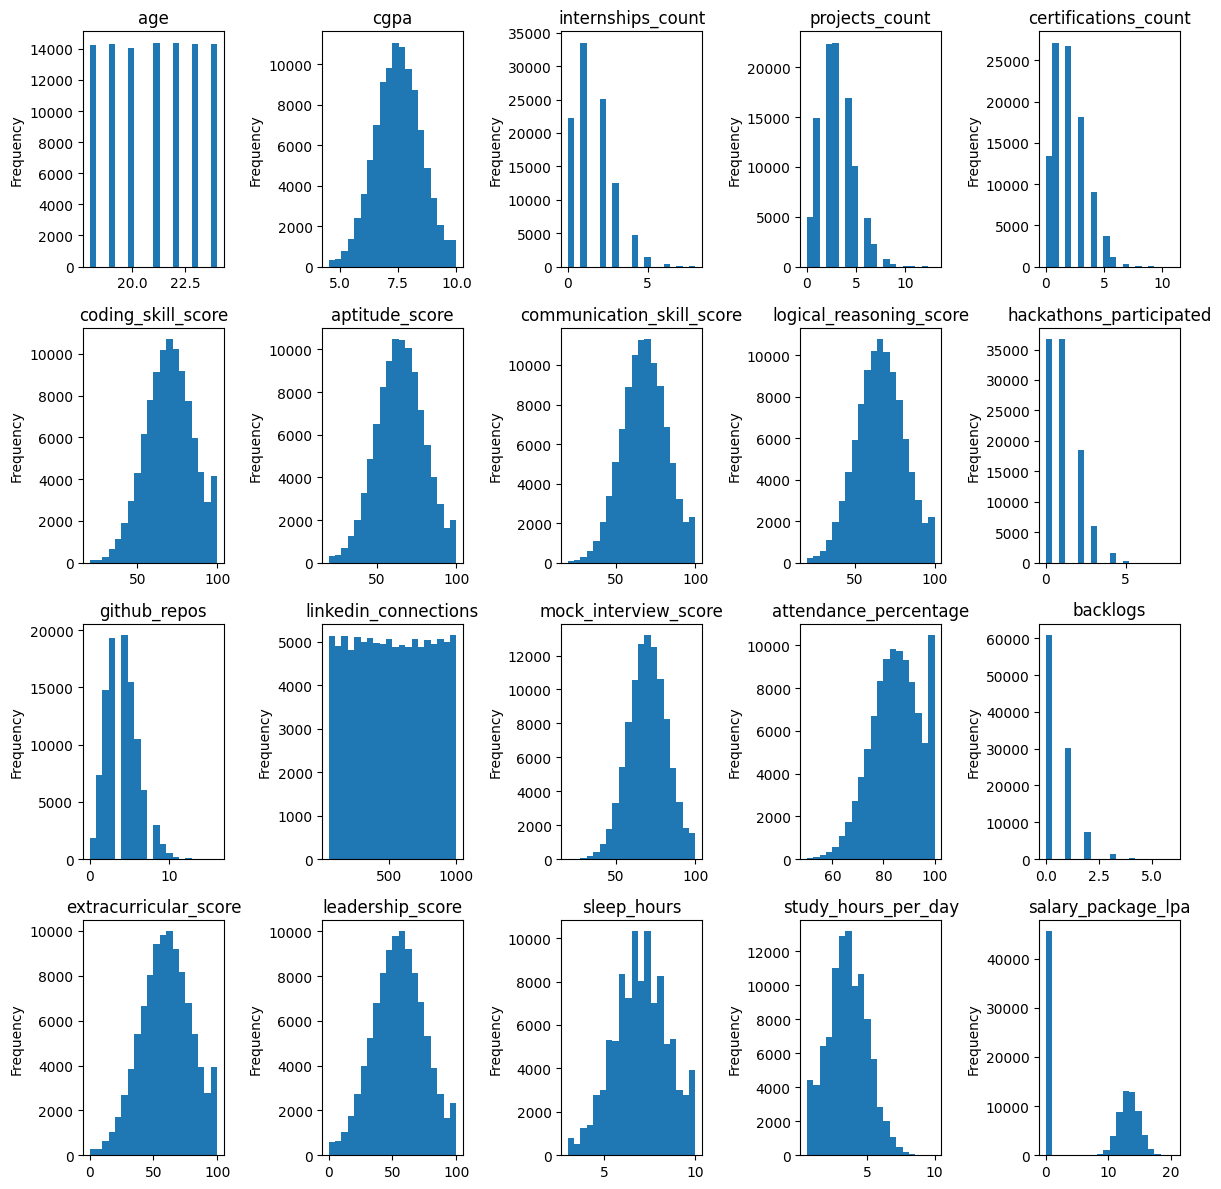

In [15]:
# Plotting histograms of numerical variables
fig, axes = plt.subplots(4, 5, figsize=(12, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_columns):
    ax.hist(df[col], bins=20)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


From the histogram plots, `age` and `linkedin_connections` appear to follow roughly uniform distributions. In contrast, aptitude-related features such as `extracurricular_score` and `mock_interview_score` resemble normal distributions, making them suitable candidates for standardization in future modeling.

The target variable, `salary_package_lpa`, shows a sharp spike at 0, representing unplaced students with no salary. Excluding this spike, the remaining values exhibit an approximately normal distribution.

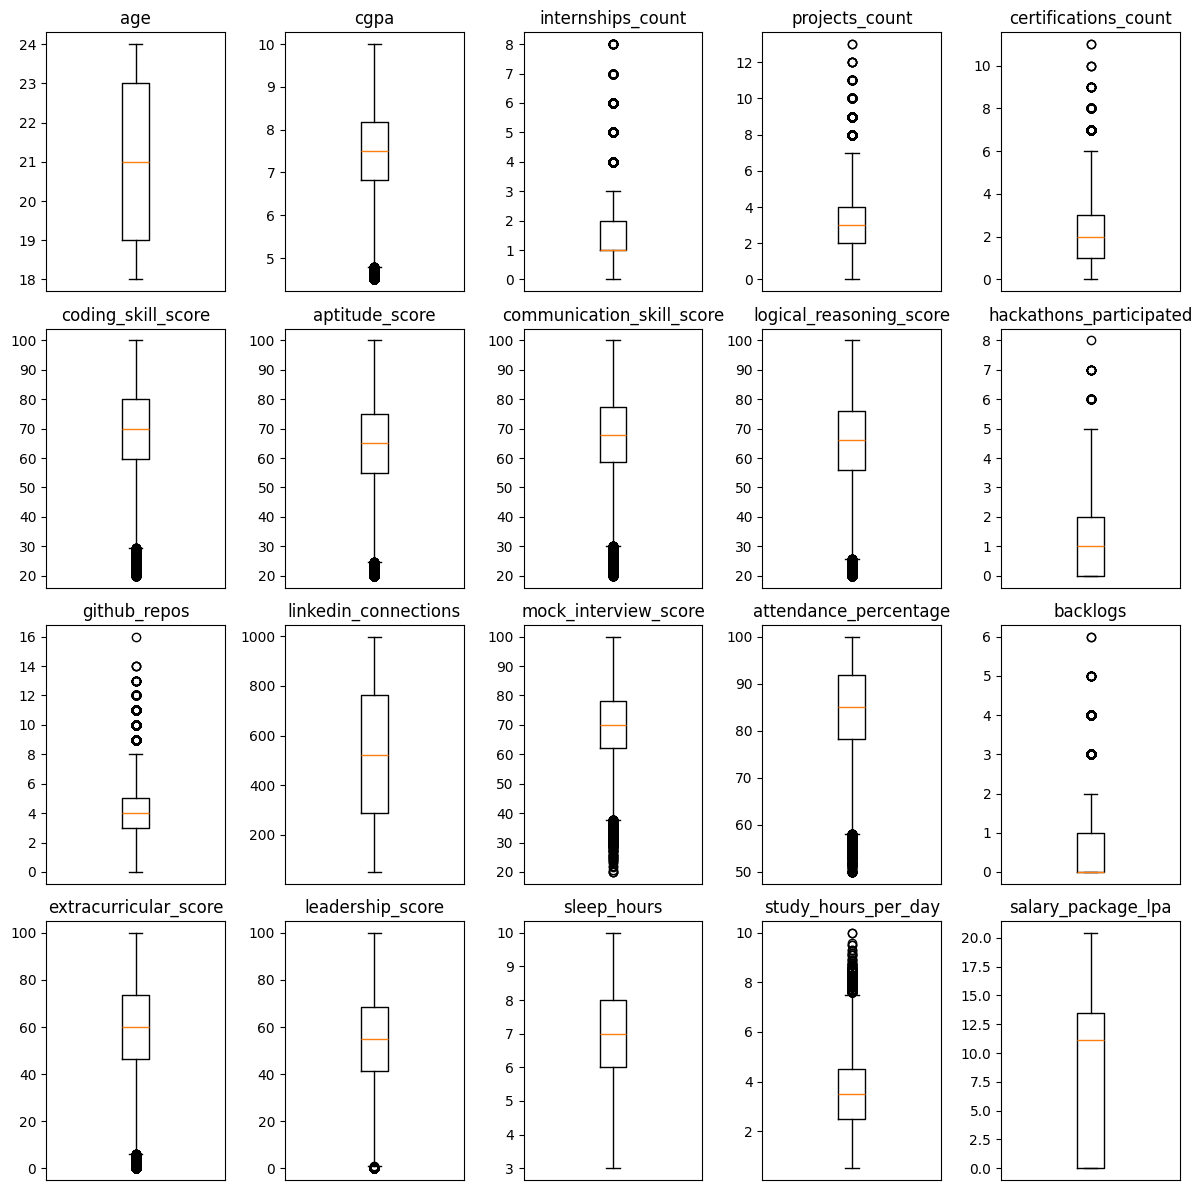

In [16]:
# Boxplot of numerical columns
fig, axes = plt.subplots(4, 5, figsize=(12, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_columns):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_xticks([])

plt.tight_layout()
plt.show()


From the boxplots, no extreme outliers appear to be data entry errors; the observed outliers seem reasonable. However, for `salary_package_lpa`, the boxplot statistics are skewed by the zero values from unplaced students, and therefore do not accurately represent the salary distribution of placed students.

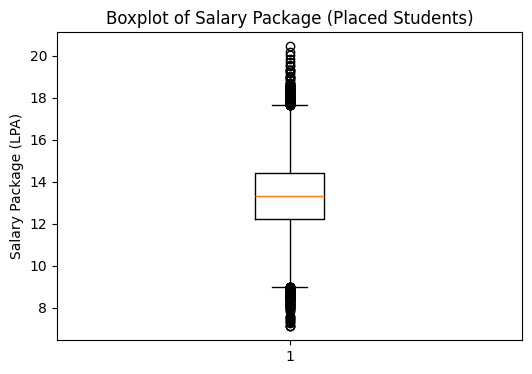

In [17]:
# Boxplot of salary_package of students with placement
placed_salary = df.loc[df.placement_status == "Placed", "salary_package_lpa"]

plt.figure(figsize=(6, 4))
plt.boxplot(placed_salary.dropna())
plt.title("Boxplot of Salary Package (Placed Students)")
plt.ylabel("Salary Package (LPA)")
plt.show()

In [18]:
# Summary statistics of placed students salaries
placed_salary.describe()

count    54459.000000
mean        13.316635
std          1.592418
min          7.110000
25%         12.230000
50%         13.300000
75%         14.390000
max         20.440000
Name: salary_package_lpa, dtype: float64

The average salary among placed students is approximately 13.3 lakh per annum.

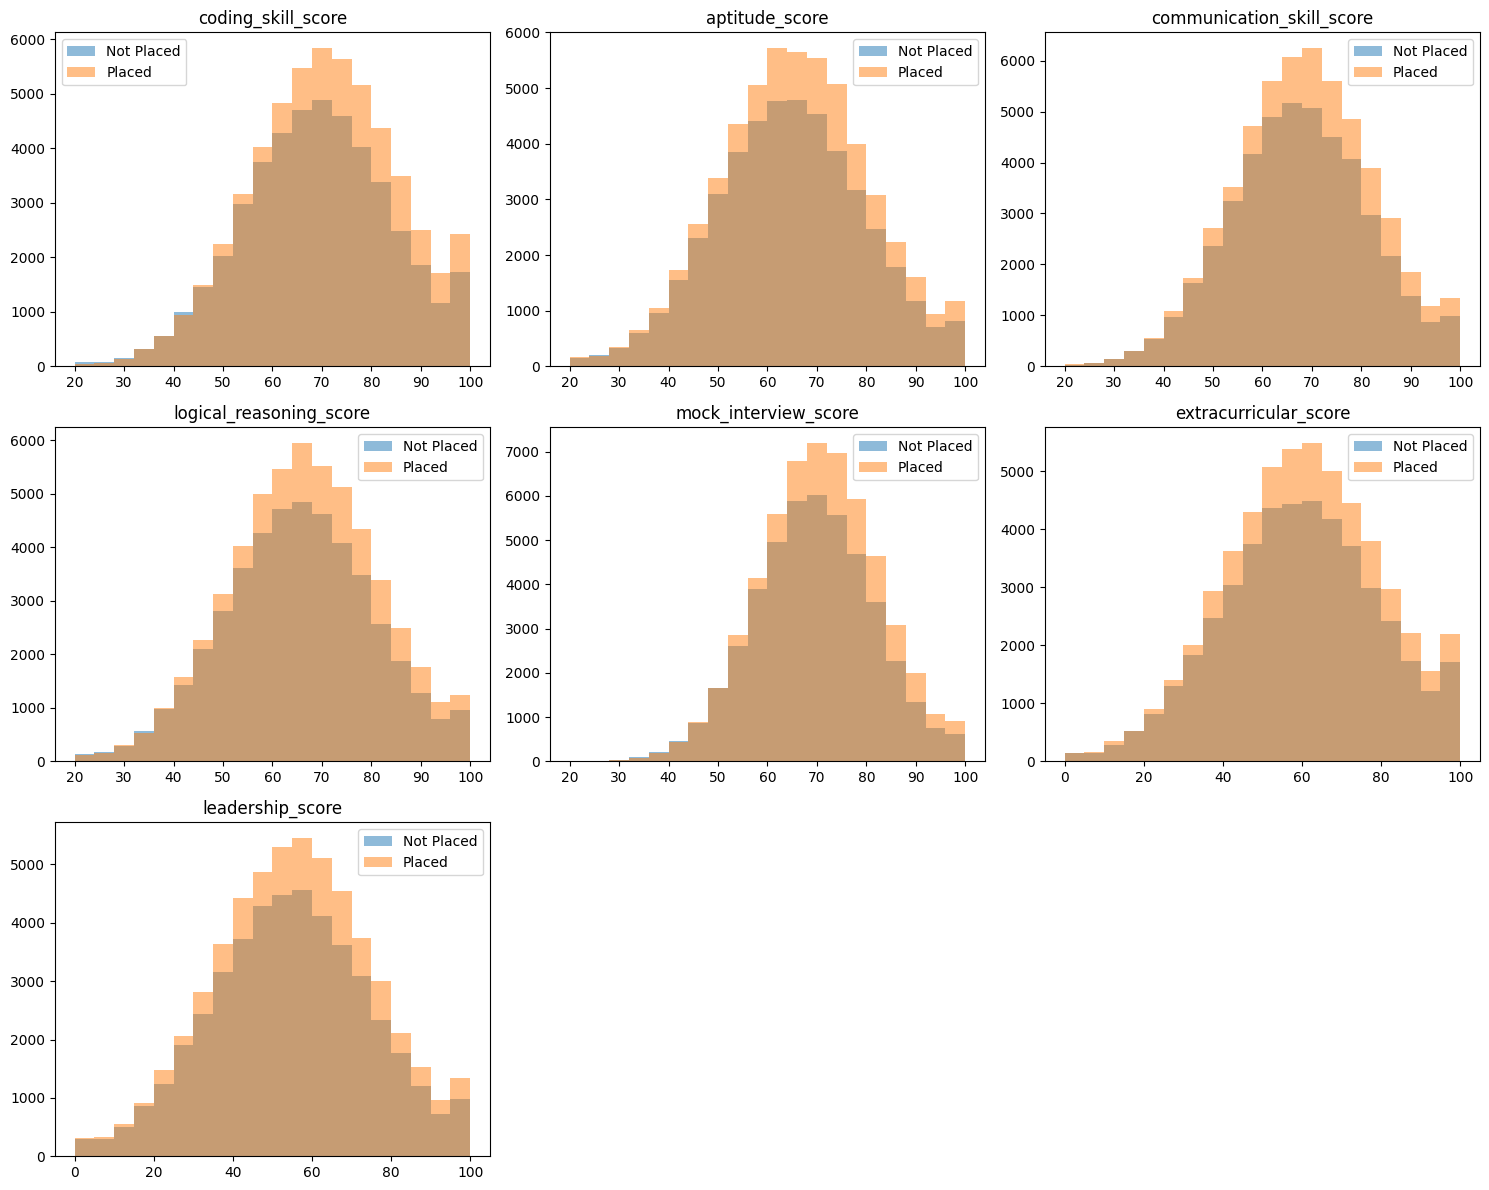

In [19]:
# Color-Coded Histograms by Placement Status
score_cols = [
    "coding_skill_score",
    "aptitude_score",
    "communication_skill_score",
    "logical_reasoning_score",
    "mock_interview_score",
    "extracurricular_score",
    "leadership_score"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, score_cols):
    placed = df[df["placement_status"] == "Placed"][col]
    not_placed = df[df["placement_status"] == "Not Placed"][col]
    
    ax.hist(not_placed, bins=20, alpha=0.5, label="Not Placed")
    ax.hist(placed, bins=20, alpha=0.5, label="Placed")
    
    ax.set_title(col)
    ax.legend()

# Remove unused subplots
for i in range(len(score_cols), 9):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


The score distributions for placed and unplaced students largely overlap, with only slight shifts toward higher scores among placed students. This suggests that higher individual scores alone may not strongly predict placement outcomes.

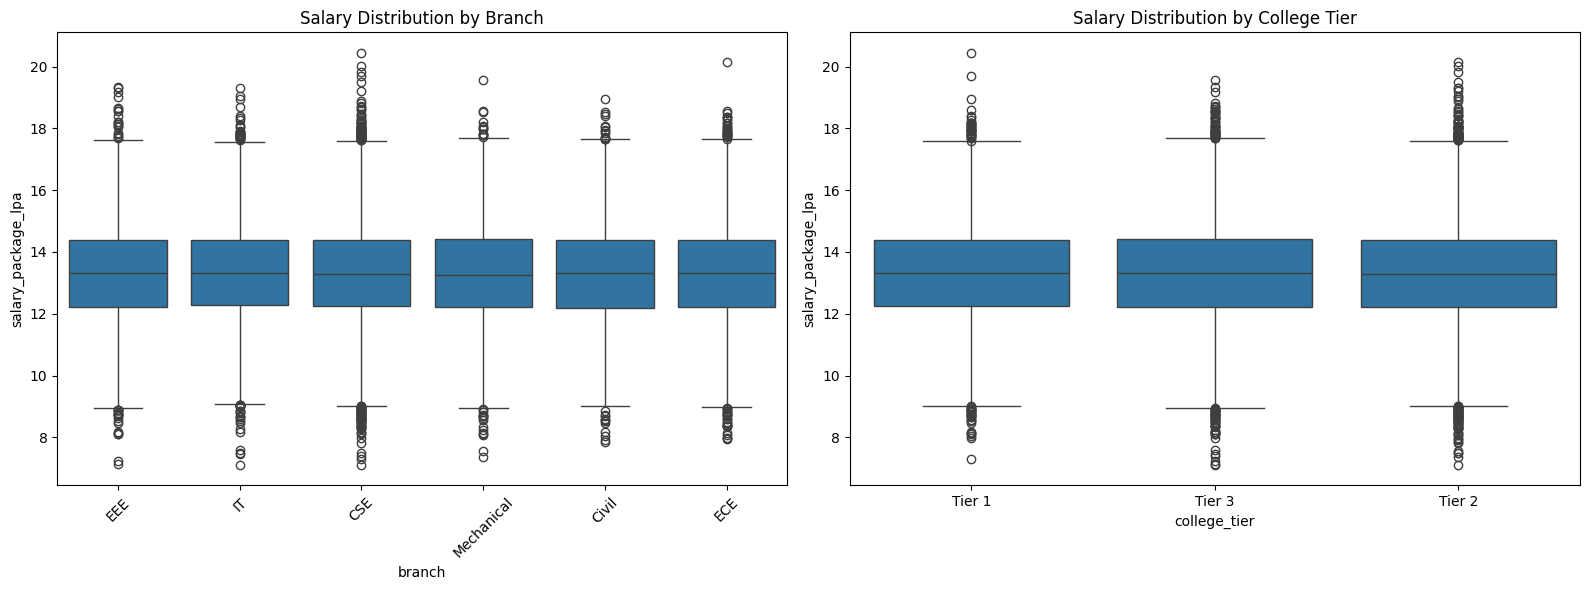

In [20]:
# Salary Variation by Branch and College Tier (Boxplots)
placed_df = df[df["placement_status"] == "Placed"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Salary by Branch
sns.boxplot(
    data=placed_df,
    x="branch",
    y="salary_package_lpa",
    ax=axes[0]
)
axes[0].set_title("Salary Distribution by Branch")
axes[0].tick_params(axis='x', rotation=45)

# Salary by College Tier
sns.boxplot(
    data=placed_df,
    x="college_tier",
    y="salary_package_lpa",
    ax=axes[1]
)
axes[1].set_title("Salary Distribution by College Tier")

plt.tight_layout()
plt.show()

Based on these boxplots, salary outcomes among placed students appear broadly similar across both branch and college tier.

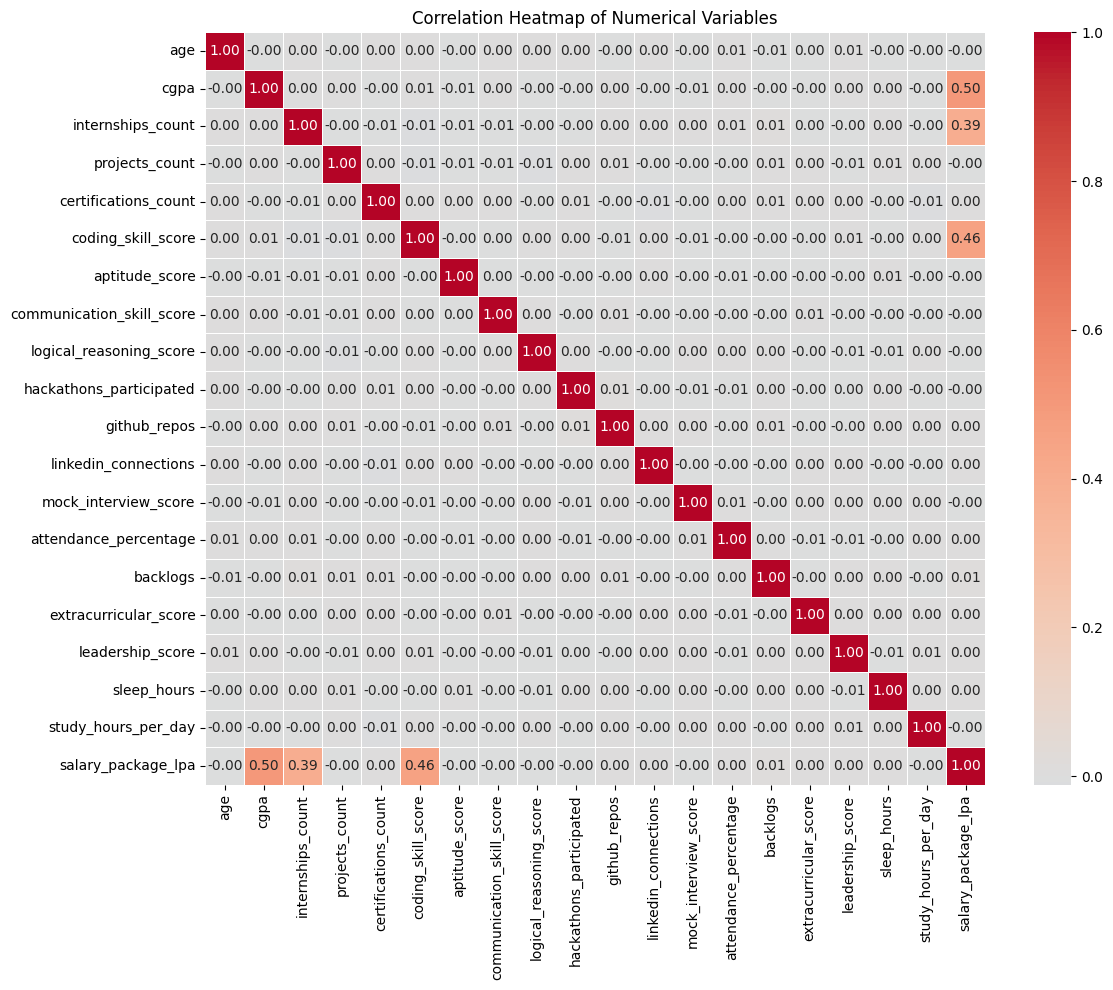

In [21]:
# Select numeric columns
numeric_df = df[df.placement_status == 'Placed'][num_columns]

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()


From the correlation heatmap, `linkedin_connections` showed no correlation with salary. Among all variables, `cgpa` appears to have the strongest positive correlation with `salary_package_lpa`, followed by `coding_skill_score` and `internships_count`. Other aptitude-related features, such as `aptitude_score` and `leadership_score`, showed no correlations with salary, suggesting they may have limited influence on compensation levels. The number of `study_hours_per_day` surprisingly had no correlation with salaries too.

## Conclusion

Overall, the dataset is clean and internally consistent, enabling reliable EDA. Placement outcomes are slightly above half of the cohort, and placed-student salaries cluster tightly around ~13 LPA. Salary appears more closely linked to **academic performance (CGPA)** and **market-aligned signals (coding skill, internship exposure)** than to networking volume (`linkedin_connections`) or lifestyle variables (`study_hours_per_day`). Additionally, most aptitude/soft-skill score distributions overlap heavily between placed and unplaced groups, implying placement may depend on **combinations of factors** rather than any single score.